In [342]:
import sys
sys.dont_write_bytecode = True

sys.path.insert(0, "/ubc/cs/research/beaver/projects/carlos/spatial_totalvi/model/src/")
from scvi.model._totalvi import TOTALVI

from graph.graph import prep_graph_splits

### Run spatial totalVI as development progresses 

In [343]:
import torch
import numpy as np
import mudata as md
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [355]:
path_to_mdata = "/ubc/cs/research/beaver/projects/carlos/spatial_totalvi/data/tonsil/tonsil_pp_svg.h5mu"
path_to_model = "/ubc/cs/research/beaver/projects/carlos/spatial_totalvi/data/trained_models/sim_inv/totalvi_k5_1layer_SGC_k1.pt"
path_to_fig = "/ubc/cs/research/beaver/projects/carlos/spatial_totalvi/figures/spatial/sim_inv/" + path_to_model.split("/")[-1].split(".pt")[0]

In [356]:
mdata = md.read_h5mu(path_to_mdata)
mdata

/ubc/cs/research/beaver/projects/carlos/conda_envs/totalvi/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/ubc/cs/research/beaver/projects/carlos/conda_envs/totalvi/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 2492 × 1267
  2 modalities
    RNA:	2492 x 984
      obs:	'leiden'
      uns:	'leiden', 'leiden_colors', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap', 'pos'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'
    Protein:	2492 x 283
      obs:	'leiden'
      uns:	'leiden', 'leiden_colors', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap', 'pos'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'

In [357]:
model = TOTALVI.load(
    path_to_model,
    mdata
)
model.module.gnn

INFO     File                                                                                                      
         /ubc/cs/research/beaver/projects/carlos/spatial_totalvi/data/trained_models/sim_inv/totalvi_k5_1layer_SGC_
         k1.pt/model.pt already downloaded                                                                         
INFO     Computing empirical prior initialization for protein background.                                          


/ubc/cs/research/beaver/projects/carlos/conda_envs/totalvi/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /ubc/cs/research/beaver/projects/carlos/conda_envs/t ...


GraphNetworkTOTALVI(
  (convs): ModuleList(
    (0): SGConv(20, 20, K=1)
  )
  (norms): ModuleList(
    (0): LayerNorm(20, affine=True, mode=graph)
  )
)

In [358]:
rna = mdata.mod["RNA"]
protein = mdata.mod["Protein"]

# Getting latents
TOTALVI_LATENT_KEY = "X_totalVI"
rna.obsm[TOTALVI_LATENT_KEY] = model.get_latent_representation(
    batch_size=mdata.n_obs
)

# Clustering latents
TOTALVI_CLUSTERS_KEY = "leiden_totalVI"
sc.pp.neighbors(rna, use_rep=TOTALVI_LATENT_KEY)
sc.tl.umap(rna)
kmeans = KMeans(n_clusters=7, random_state=0)
rna.obs[TOTALVI_CLUSTERS_KEY] = kmeans.fit_predict(rna.obsm[TOTALVI_LATENT_KEY]).astype(str)

In [359]:
parsed_protein_names = [p.split("_")[0] for p in protein.var_names]
protein.var["clean_names"] = parsed_protein_names
mdata.update()

/ubc/cs/research/beaver/projects/carlos/conda_envs/totalvi/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/ubc/cs/research/beaver/projects/carlos/conda_envs/totalvi/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


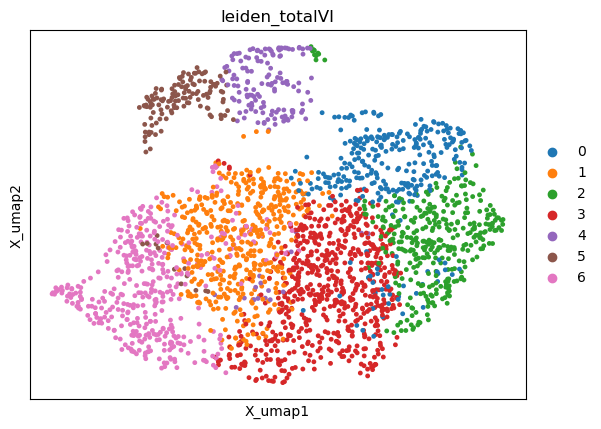

In [360]:
sc.pl.embedding(
    mdata["RNA"],
    basis="X_umap",
    color=f"{TOTALVI_CLUSTERS_KEY}",
    ncols=1,
    show=False
)
plt.savefig(path_to_fig + "_latent_space.png", dpi=400, bbox_inches="tight")

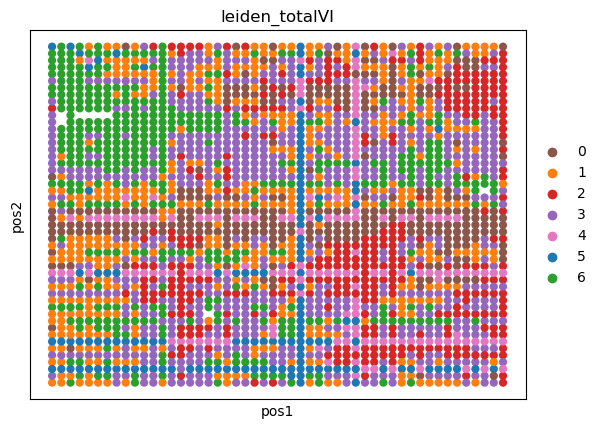

In [366]:
sc.pl.embedding(
    mdata["RNA"],
    basis="pos",
    color=f"{TOTALVI_CLUSTERS_KEY}",
    s=140,
    ncols=1,
    show=False,
    palette={
        "0": "tab:brown",   # was blue
        "1": "tab:orange", 
        "2": "tab:red",
        "3": "tab:purple",
        "4": "tab:pink",
        "5": "tab:blue",    # was brown
        "6": "tab:green",
    }
)
plt.gca().invert_yaxis()
plt.savefig(path_to_fig + "_spatial_latent_clusters.png", dpi=400, bbox_inches="tight")

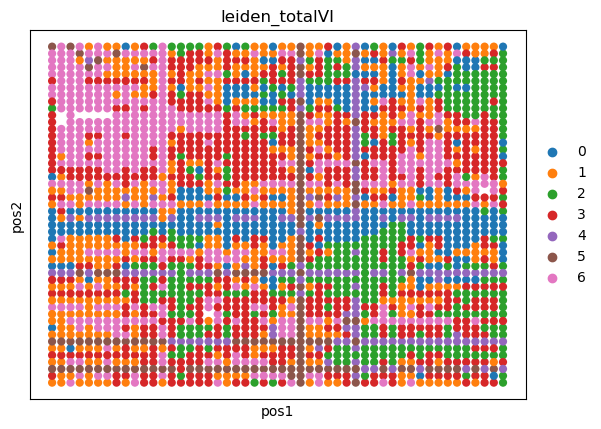

In [362]:
sc.pl.embedding(
    mdata["RNA"],
    basis="pos",
    color=f"{TOTALVI_CLUSTERS_KEY}",
    s=140,
    ncols=1,
    show=False
)
plt.gca().invert_yaxis()
plt.savefig(path_to_fig + "_spatial_latent_clusters.png", dpi=400, bbox_inches="tight")

In [363]:
# import numpy as np
# np.savetxt(
#     X=mdata["RNA"].obsm["X_totalVI"],
#     fname="/ubc/cs/research/beaver/projects/carlos/spatial_totalvi/data/tonsil/latents_sptotalvi.tsv",
#     delimiter="\t"
# )

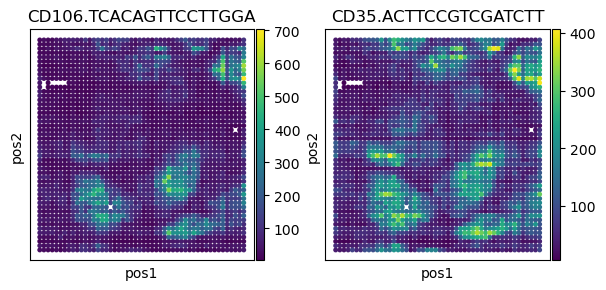

In [364]:
# From OG paper: markers for clusters 2/5
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7, 3))

sc.pl.embedding(mdata["Protein"], basis="pos", color="CD106.TCACAGTTCCTTGGA", s=50, show=False, ax=ax[0])
ax[0].invert_yaxis()

sc.pl.embedding(mdata["Protein"], basis="pos", color="CD35.ACTTCCGTCGATCTT", s=50, show=False, ax=ax[1])
ax[1].invert_yaxis()

# plt.savefig(path_to_fig + "_spatial_latent_GC_markers.png", dpi=400, bbox_inches="tight")

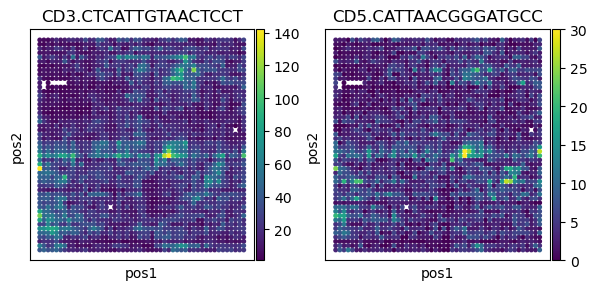

In [365]:
# From OG paper: markers for cluster 1
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7, 3))

sc.pl.embedding(mdata["Protein"], basis="pos", color="CD3.CTCATTGTAACTCCT", s=50, show=False, ax=ax[0])
ax[0].invert_yaxis()

sc.pl.embedding(mdata["Protein"], basis="pos", color="CD5.CATTAACGGGATGCC", s=50, show=False, ax=ax[1])
ax[1].invert_yaxis()
